#  Customer Payment Probability Prediction
### Loan Recovery Analysis — Feb 2023 to Jul 2023

---

**Objective:** Build a classifier that predicts whether a customer in loan recovery will make a payment in a given month.

**Dataset:** 6-month window (Feb '23 – Jul '23) covering ~348,000 account-month records across 27 fields — including outstanding principal, days-past-due, EMI amounts, CIBIL scores, and borrower demographics.



---

## 1. Setup — Importing Libraries

We start by loading all the libraries we'll need throughout this notebook. I

- **pandas / numpy** — for data wrangling and numerical operations
- **matplotlib / seaborn** — for all our charts and visualisations
- **sklearn** — for building and evaluating our machine learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual theme for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Load & Inspect the Data

Let's load the CSV and take a quick first look. We want to confirm:
- How many rows and columns we have
- Which months are covered
- What the first few records look like



In [2]:
df = pd.read_csv('Data_6Months.csv')

print(f"Dataset shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"\nMonths covered (month_end_date): {sorted(df['month_end_date'].unique())}")
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: 348,151 rows  x  27 columns

Months covered (month_end_date): ['2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30', '2023-07-31']

First 3 rows:


,Account_number,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disbursal_date,disb_amt,tenor,roi,emi,...,final_veri_monthly_income,writeoff_date,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,Pmt_amount,month_end_date
0,1.151000e+11,0.0,4380.0,NCL,PL_SELF,27/01/09 00:00,105000.0,24.0,32.380001,6035.0,...,NaN,01-Jun-11,5884.0,146.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
1,1.152000e+11,0.0,0.0,NCL,PL_SELF,12/09/08 00:00,200000.0,20.0,22.969999,12065.0,...,NaN,01-Sep-10,11844.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
2,1.152000e+11,0.0,4046.0,NCL,PL_SELF,28/12/08 00:00,650000.0,36.0,22.219999,24993.0,...,NaN,01-May-12,24464.0,148.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28


---
## 3. Data Quality Check

Before touching anything, we need to understand what we're working with. This section produces our **one-page data-quality summary** as required by the assignment.

We check for:
- Columns with missing values and how severe they are
- Hidden nulls (like `cibil_score = 0`, which means 'no data', not an actual score of zero)
- The distribution of our target variable `Pmt_amount` — and whether we have a class imbalance problem

In [3]:
# Build a clean summary table of missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype':         df.dtypes
}).sort_values('Missing %', ascending=False)

print("=== Missing Value Summary ===")
print(missing[missing['Missing Count'] > 0].to_string())

# CIBIL score of 0 is not a real score — it means 'no credit history'
# We treat these as hidden nulls
hidden_nulls = (df['cibil_score'] == 0).sum()
print(f"\nCIBIL score rows where value is exactly 0 (hidden nulls): {hidden_nulls:,}")

# Target variable: Pmt_amount
print("\n=== Target Variable: Pmt_amount ===")
print(df['Pmt_amount'].describe().round(2))

payers      = (df['Pmt_amount'].fillna(0) > 0).sum()
total_valid = df['Pmt_amount'].notna().sum()
print(f"\nAccounts that made any payment: {payers:,} out of {total_valid:,} ({payers/total_valid*100:.1f}%)")
print(f"Negative Pmt_amount rows (likely reversals or corrections): {(df['Pmt_amount'] < 0).sum():,}")

=== Missing Value Summary ===
                           Missing Count  Missing %    Dtype
total_work_exp_months             329406      94.62  float64
industry_type                     329415      94.62   object
emp_type                          329406      94.62   object
total_outstanding                 290960      83.57   object
final_veri_monthly_income         108460      31.15  float64
final_dbr                         105000      30.16  float64
pincode                            87292      25.07  float64
residence_state                    25430       7.30   object
residence_city                     25431       7.30   object
cibil_score                        10928       3.14  float64
source                              8015       2.30   object
loan_program_type                   1559       0.45   object
Pmt_amount                          1154       0.33  float64
dpd_days_wo                          159       0.05  float64
roi                                  149       0.04  fl

### Data Quality Summary — Visual

The chart on the left shows which columns have missing data and how bad it is:
- **Red bars** (>80% missing) → these columns will be dropped; too little data to be useful
- **Orange bars** (30–80% missing) → handle with imputation
- **Blue bars** (<30% missing) → straightforward to fill

The pie chart on the right confirms our class imbalance — only about **9% of account-months** result in a payment. This matters a lot for how we train our model.

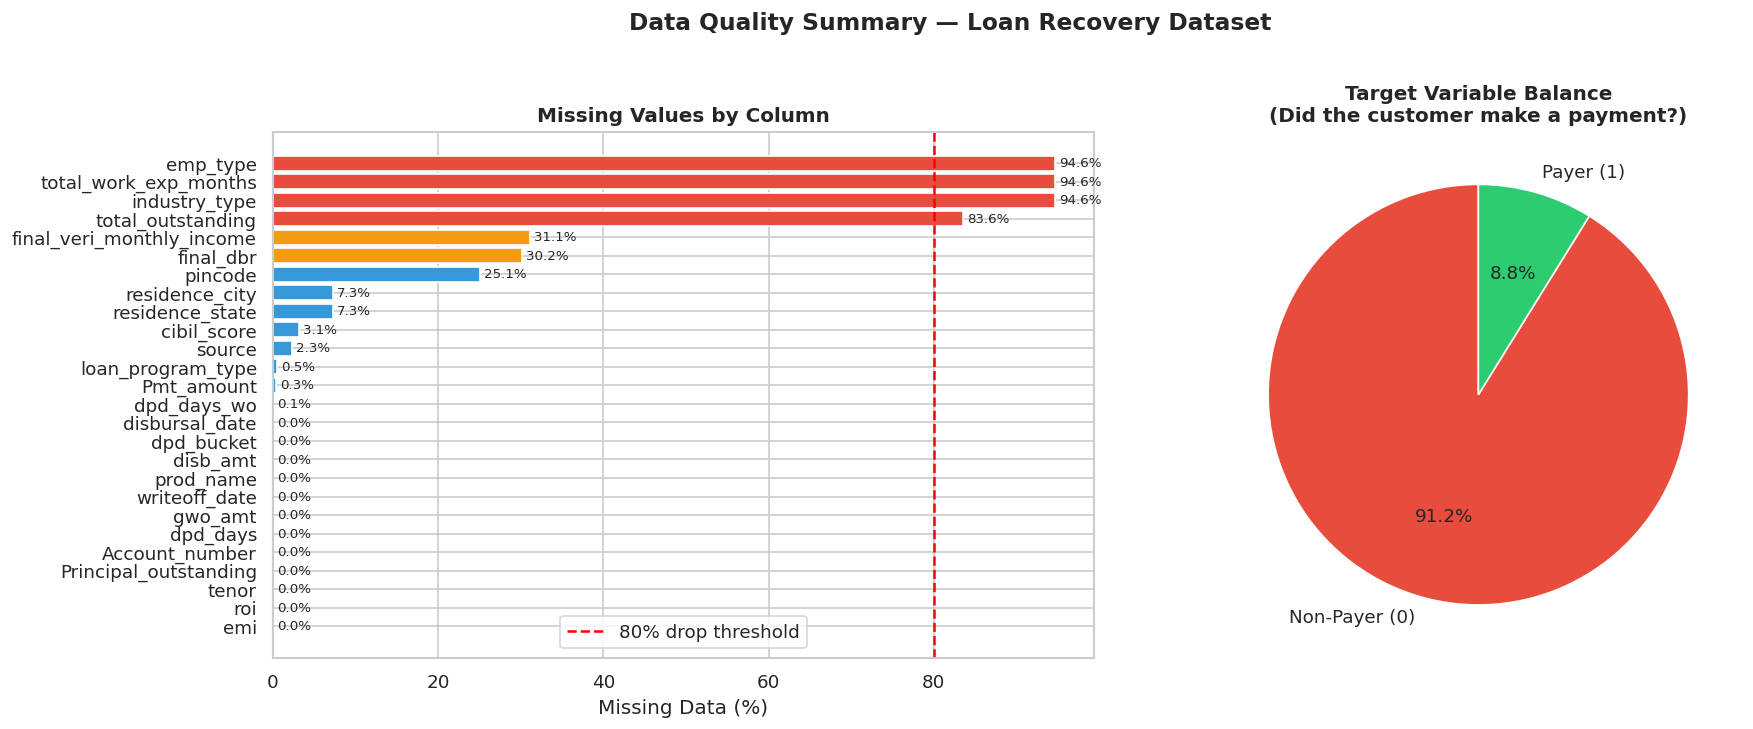

Saved: data_quality_summary.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality Summary — Loan Recovery Dataset', fontsize=14, fontweight='bold', y=1.01)

# Left chart: Missing % per column
missing_plot = missing[missing['Missing %'] > 0]['Missing %'].sort_values()
colors       = ['#e74c3c' if v > 80 else '#f39c12' if v > 30 else '#3498db' for v in missing_plot.values]
bars         = axes[0].barh(missing_plot.index, missing_plot.values, color=colors)

axes[0].axvline(x=80, color='red', linestyle='--', linewidth=1.5, label='80% drop threshold')
axes[0].set_xlabel('Missing Data (%)')
axes[0].set_title('Missing Values by Column', fontweight='bold')
axes[0].legend()

for bar, val in zip(bars, missing_plot.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8)

# Right chart: Target class balance
labels     = ['Non-Payer (0)', 'Payer (1)']
sizes      = [total_valid - payers, payers]
pie_colors = ['#e74c3c', '#2ecc71']

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Target Variable Balance\n(Did the customer make a payment?)', fontweight='bold')

plt.tight_layout()
plt.savefig('data_quality_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data_quality_summary.png")

---
## 4. Data Cleaning

Based on the quality check, here's our cleaning plan:

| Issue | Action |
|---|---|
| Columns >80% missing | Drop them entirely |
| `cibil_score` = 0 | Treat as null; create a `cibil_missing_flag` column |
| Other numeric nulls | Fill with column median |
| Categorical nulls | Replace with 'Unknown' |
| Negative `Pmt_amount` | Clip to 0 (treat as reversals) |
| Date columns | Parse to proper datetime format |

## Data Cleaning & Preprocessing

- Removed high-missing columns (>80%)
- Created target variable (is_payer)
- Handled missing values using median imputation
- Treated invalid CIBIL scores (0, -1)
- Converted date columns and sorted dataset chronologically
- Removed leakage-prone features from processing

We also engineer two new features:
- **`cibil_missing_flag`** — tells the model whether a borrower has no credit history (very different from having a low score)
- **`loan_age_days`** — how old the loan is; models can't learn from raw dates, but they can learn from a number

In [5]:
df_clean = df.copy()

# --- Step 1: Drop columns that are >80% empty ---
cols_to_drop = ['industry_type', 'emp_type', 'total_work_exp_months', 'total_outstanding']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped columns (>80% missing): {cols_to_drop}")

# --- Step 2: Handle the target variable ---
df_clean = df_clean.dropna(subset=['Pmt_amount'])
df_clean['Pmt_amount'] = df_clean['Pmt_amount'].clip(lower=0)
df_clean['is_payer']   = (df_clean['Pmt_amount'] > 0).astype(int)

# --- Step 3: CIBIL score — flag hidden nulls before filling ---
df_clean['cibil_score']        = df_clean['cibil_score'].replace([0, -1], np.nan)
df_clean['cibil_missing_flag'] = df_clean['cibil_score'].isna().astype(int)
df_clean['cibil_score']        = df_clean['cibil_score'].fillna(df_clean['cibil_score'].median())

# --- Step 4: Fill remaining numeric columns with median ---
numeric_fill = ['final_veri_monthly_income', 'final_dbr', 'disb_amt',
                'roi', 'emi', 'pincode']

for col in numeric_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- Step 5: Clean categorical columns ---
cat_cols = ['residence_state', 'residence_city', 'source', 'loan_program_type', 'dpd_bucket', 'prod_name']
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).replace({'nan': 'Unknown', '<NA>': 'Unknown'})

# --- Step 6: Parse dates ---
df_clean['month_end_date'] = pd.to_datetime(df_clean['month_end_date'], errors='coerce')
df_clean['disbursal_date'] = pd.to_datetime(df_clean['disbursal_date'], dayfirst=True, errors='coerce')

df_clean = df_clean.sort_values('month_end_date')

# --- Step 7: Feature — Loan Age in Days ---
df_clean['loan_age_days'] = (df_clean['month_end_date'] - df_clean['disbursal_date']).dt.days
df_clean['loan_age_days'] = df_clean['loan_age_days'].fillna(df_clean['loan_age_days'].median())

print(f"\nClean dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print("\nTarget split:")
print(df_clean['is_payer'].value_counts(normalize=True).mul(100).round(1).rename({1: 'Payer %', 0: 'Non-Payer %'}))

Dropped columns (>80% missing): ['industry_type', 'emp_type', 'total_work_exp_months', 'total_outstanding']

Clean dataset: 346,997 rows, 26 columns

Target split:
is_payer
Non-Payer %    91.2
Payer %         8.8
Name: proportion, dtype: float64


### Outlier Treatment — 99th Percentile Capping

A few financial columns have extreme outliers that can distort both our charts and our model. For example, a single loan with a principal of ₹10 crore would make all the other bars look flat in a histogram.

We cap values at the **99th percentile** — this preserves the natural distribution while removing the extreme tail. We're not deleting these rows, just limiting the extreme values.

In [6]:
cols_to_cap = ['Principal_outstanding', 'disb_amt', 'emi', 'final_veri_monthly_income']

print("Outlier capping at 99th percentile:")
for col in cols_to_cap:
    cap    = df_clean[col].quantile(0.99)
    n_rows = (df_clean[col] > cap).sum()
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"  {col}: capped {n_rows:,} rows at {cap:,.0f}")

# Quick sanity check on monthly payer rates
monthly_rate = (
    df_clean
    .groupby(df_clean['month_end_date'].dt.strftime('%Y-%m'))['is_payer']
    .mean()
    .mul(100)
    .round(2)
)

print("\nMonthly payment rate (% of accounts that paid in each month):")
print(monthly_rate.to_string())

Outlier capping at 99th percentile:
  Principal_outstanding: capped 3,466 rows at 952,567
  disb_amt: capped 3,465 rows at 1,042,564
  emi: capped 3,460 rows at 34,515
  final_veri_monthly_income: capped 3,468 rows at 66,449

Monthly payment rate (% of accounts that paid in each month):
month_end_date
2023-02    10.53
2023-03     9.30
2023-04     7.49
2023-05     8.70
2023-06     8.52
2023-07     8.54


---
## 5. Exploratory Data Analysis (EDA)

Now for the interesting part — let's understand what's actually in this data.

### 5.1 Account Distribution

We look at how accounts are spread across three dimensions:
- **DPD Bucket** — how overdue are the loans?
- **Product Name** — which loan products dominate the portfolio?
- **State** — where are the borrowers located?

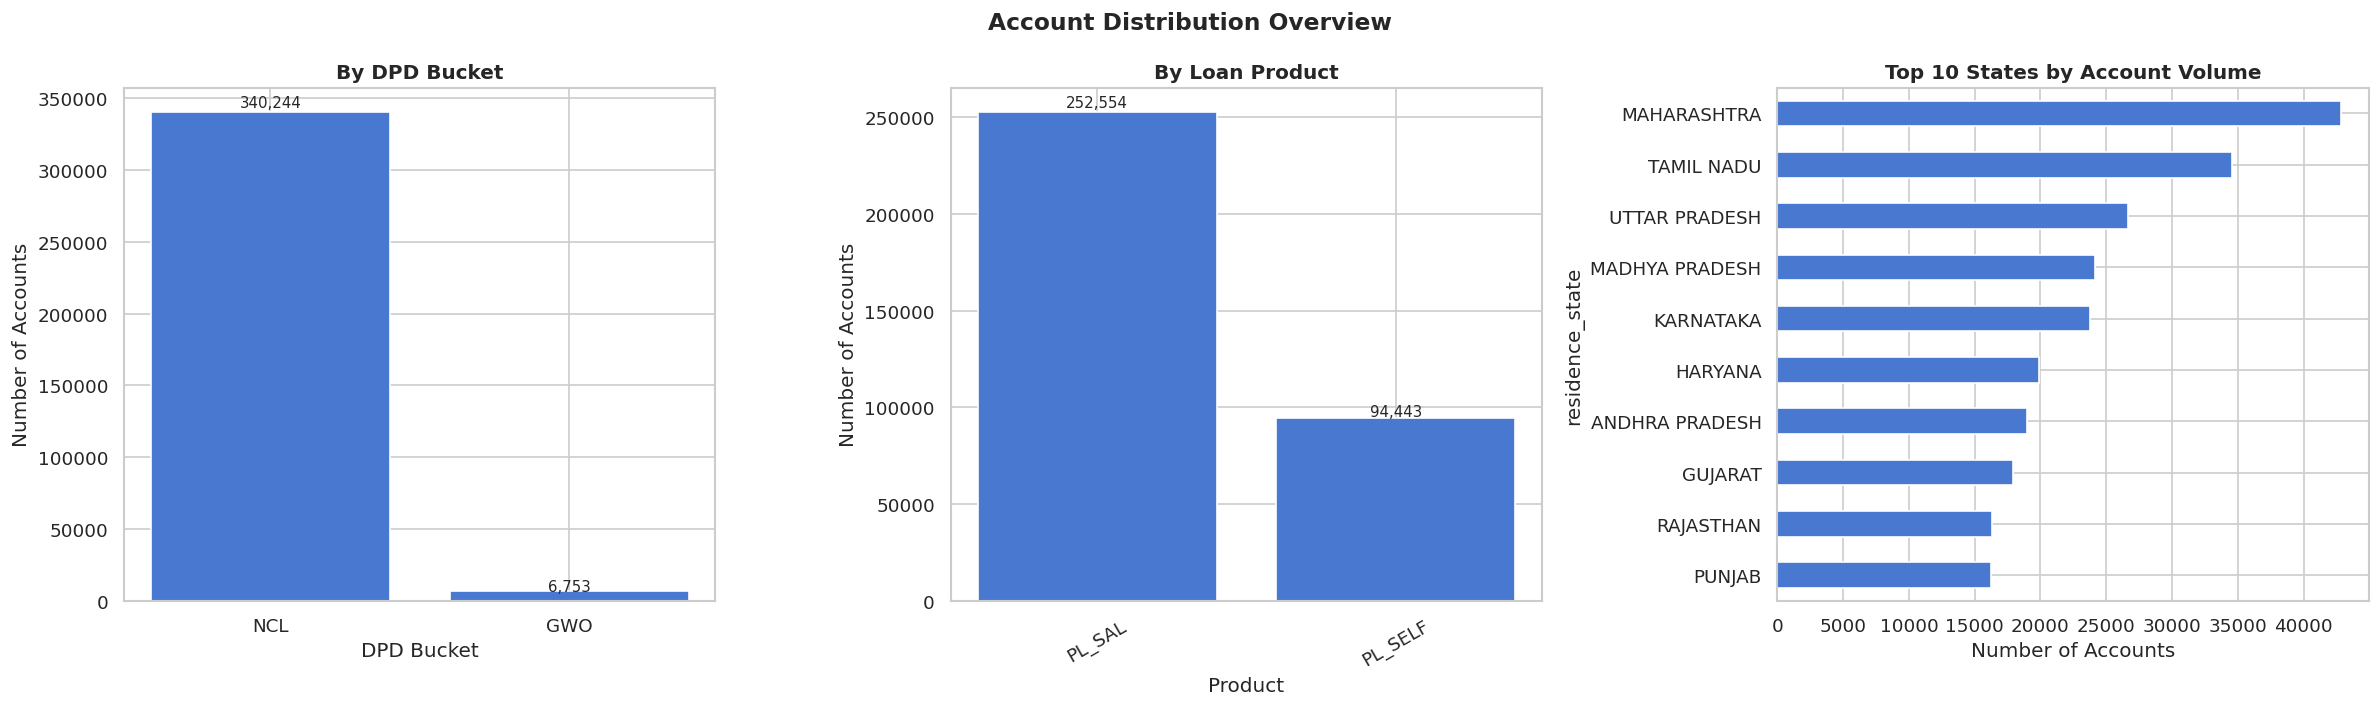

Saved: eda_distribution.png


In [7]:
id="improved_eda"
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Account Distribution Overview', fontsize=14, fontweight='bold')

# --- Chart 1: Distribution by DPD Bucket ---
dpd_counts = df_clean['dpd_bucket'].value_counts()

bars1 = axes[0].bar(dpd_counts.index, dpd_counts.values)
axes[0].set_title('By DPD Bucket', fontweight='bold')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_xlabel('DPD Bucket')

# dynamic label positioning
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 height * 1.01,
                 f'{int(height):,}',
                 ha='center', fontsize=9)

# --- Chart 2: Distribution by Loan Product ---
prod_counts = df_clean['prod_name'].value_counts()

bars2 = axes[1].bar(prod_counts.index, prod_counts.values)
axes[1].set_title('By Loan Product', fontweight='bold')
axes[1].set_ylabel('Number of Accounts')
axes[1].set_xlabel('Product')
axes[1].tick_params(axis='x', rotation=30)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 height * 1.01,
                 f'{int(height):,}',
                 ha='center', fontsize=9)

# --- Chart 3: Top 10 States ---
top_states = (
    df_clean[df_clean['residence_state'] != 'Unknown']['residence_state']
    .value_counts()
    .nlargest(10)
    .sort_values()
)

top_states.plot(kind='barh', ax=axes[2])
axes[2].set_title('Top 10 States by Account Volume', fontweight='bold')
axes[2].set_xlabel('Number of Accounts')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_distribution.png")

### 5.2 Payment Trends — Month over Month

We now look at how payments evolved across the 6-month window:
- **Total EMI collected** per month (in INR)
- **Number of unique payers** per month
- **Collection amount vs payer rate** on a dual-axis chart
- **Active vs Delinquent pool** as a stacked bar

The stacked bar is particularly useful — it shows us not just payment rates, but the size of the problem at each point in time.

In [8]:
# --- Aggregate by month (time-safe approach) ---

monthly = (
    df_clean
    .groupby(df_clean['month_end_date'].dt.to_period('M'))
    .agg(
        total_collected  = ('Pmt_amount', 'sum'),
        unique_payers    = ('is_payer', 'sum'),
        total_accounts   = ('Account_number', 'count')
    )
    .reset_index()
)

# Convert period → timestamp for plotting
monthly['month_end_date'] = monthly['month_end_date'].dt.to_timestamp()

# Additional metrics
monthly['delinquent_accounts'] = monthly['total_accounts'] - monthly['unique_payers']
monthly['payer_rate_pct']      = (
    (monthly['unique_payers'] / monthly['total_accounts']) * 100
).round(2)

print("=== Monthly Payment Summary ===")
print(monthly.to_string(index=False))

=== Monthly Payment Summary ===
month_end_date  total_collected  unique_payers  total_accounts  delinquent_accounts  payer_rate_pct
    2023-02-01     148990208.26           5993           56894                50901           10.53
    2023-03-01     129282940.88           5275           56747                51472            9.30
    2023-04-01      91315822.30           4284           57170                52886            7.49
    2023-05-01     114706536.40           5088           58509                53421            8.70
    2023-06-01     126657792.41           5029           58998                53969            8.52
    2023-07-01     117245157.83           5014           58679                53665            8.54


## Payment Trends Analysis

This section evaluates month-over-month performance across key recovery metrics:

- Total EMI collected  
- Number of paying customers  
- Payer rate (%)  
- Active vs delinquent accounts  

### Key Insights:
- Trends in total collection indicate recovery efficiency over time  
- Payer rate highlights customer repayment behavior  
- Increasing delinquent pool signals potential credit risk  
- Useful for identifying seasonal or operational patterns in collections  

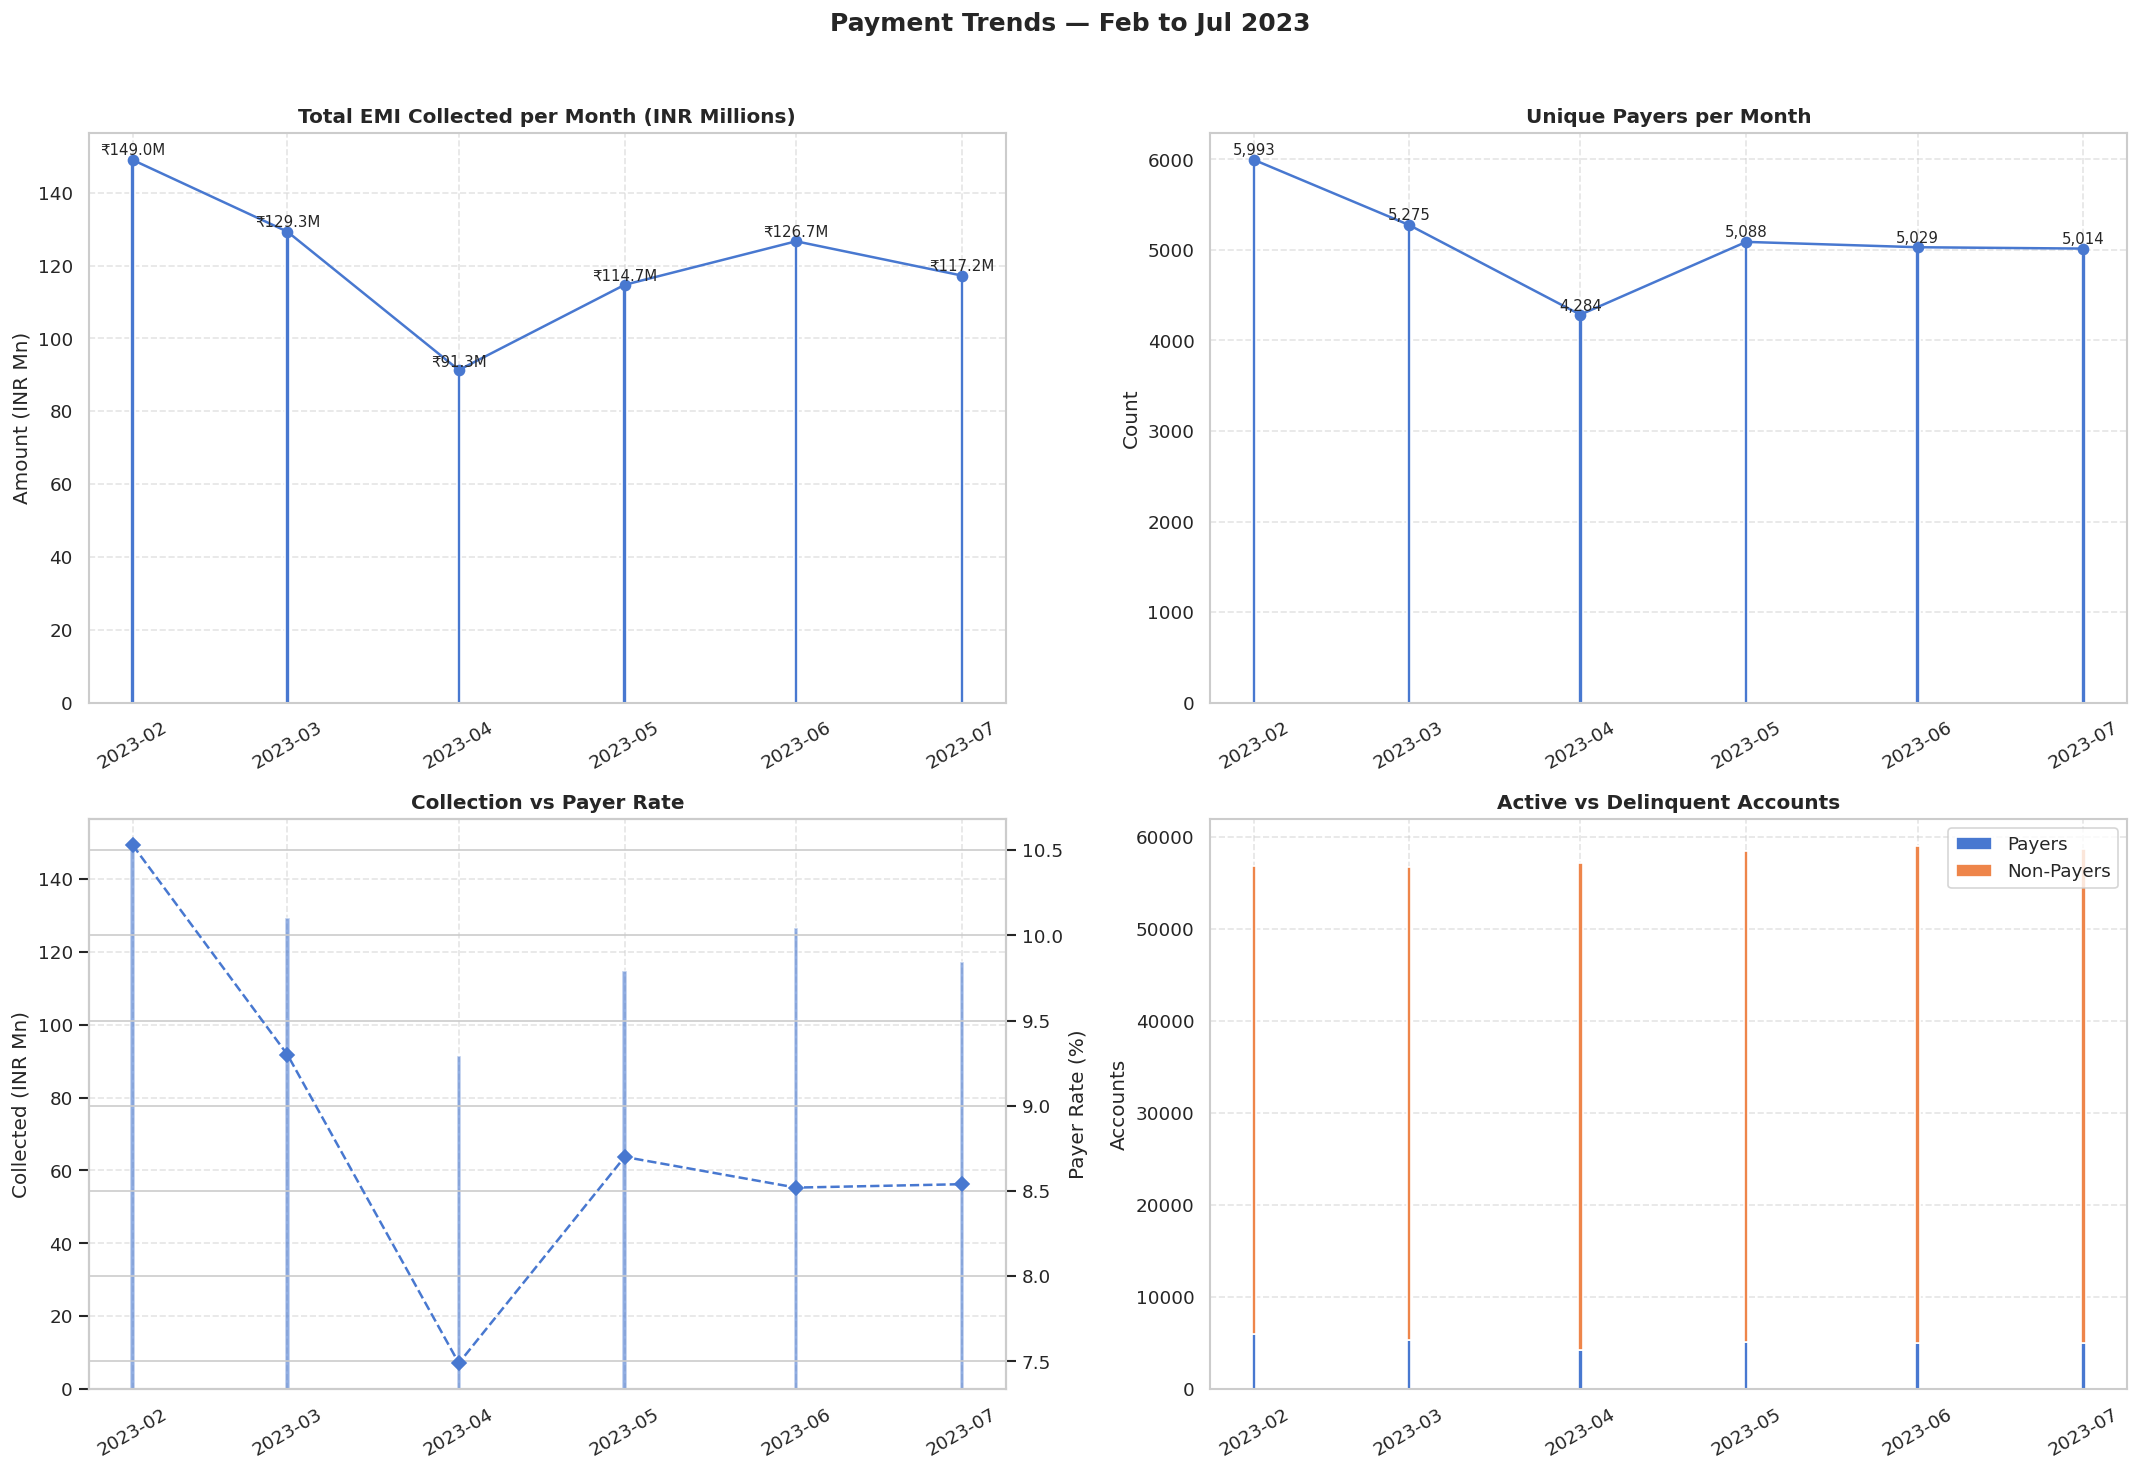

Saved: eda_payment_trends.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Payment Trends — Feb to Jul 2023', fontsize=15, fontweight='bold', y=1.02)

months = monthly['month_end_date']

# --- Chart 1: Total EMI Collected ---
axes[0, 0].bar(months, monthly['total_collected'] / 1e6)
axes[0, 0].plot(months, monthly['total_collected'] / 1e6, marker='o')

axes[0, 0].set_title('Total EMI Collected per Month (INR Millions)', fontweight='bold')
axes[0, 0].set_ylabel('Amount (INR Mn)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

for x, val in zip(months, monthly['total_collected']):
    axes[0, 0].text(x, val/1e6 * 1.01, f'₹{val/1e6:.1f}M',
                    ha='center', fontsize=9)

# --- Chart 2: Unique Payers ---
axes[0, 1].bar(months, monthly['unique_payers'])
axes[0, 1].plot(months, monthly['unique_payers'], marker='o')

axes[0, 1].set_title('Unique Payers per Month', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

for x, val in zip(months, monthly['unique_payers']):
    axes[0, 1].text(x, val * 1.01, f'{int(val):,}',
                    ha='center', fontsize=9)

# --- Chart 3: Dual Axis ---
ax_bar  = axes[1, 0]
ax_line = ax_bar.twinx()

ax_bar.bar(months, monthly['total_collected'] / 1e6, alpha=0.6)
ax_line.plot(months, monthly['payer_rate_pct'], marker='D', linestyle='--')

ax_bar.set_title('Collection vs Payer Rate', fontweight='bold')
ax_bar.set_ylabel('Collected (INR Mn)')
ax_line.set_ylabel('Payer Rate (%)')

ax_bar.grid(True, linestyle='--', alpha=0.5)

# --- Chart 4: Active vs Delinquent ---
axes[1, 1].bar(months, monthly['unique_payers'], label='Payers')
axes[1, 1].bar(months, monthly['delinquent_accounts'],
               bottom=monthly['unique_payers'], label='Non-Payers')

axes[1, 1].set_title('Active vs Delinquent Accounts', fontweight='bold')
axes[1, 1].set_ylabel('Accounts')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# --- Format X-axis ---
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_payment_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: eda_payment_trends.png")

### Insight:
A noticeable dip in April indicates a temporary decline in repayment activity, possibly due to seasonality or operational factors.

### 5.3 Overall Summary

A quick summary of the full 6-month dataset combined — useful as a headline figure for any presentation or report.

In [10]:
total_active     = df_clean['is_payer'].sum()
total_delinquent = (df_clean['is_payer'] == 0).sum()
total_pool       = len(df_clean)


unique_accounts  = df_clean['Account_number'].nunique()

total_collected  = df_clean['Pmt_amount'].sum()
avg_payment      = df_clean.loc[df_clean['is_payer'] == 1, 'Pmt_amount'].mean()

payer_pct        = (total_active / total_pool * 100) if total_pool else 0
delinq_pct       = (total_delinquent / total_pool * 100) if total_pool else 0

print("=" * 60)
print("        OVERALL PORTFOLIO SUMMARY (6 MONTHS)")
print("=" * 60)

print(f"Total Account-Month Records : {total_pool:>12,}")
print(f"Unique Accounts            : {unique_accounts:>12,}")

print("-" * 60)

print(f"Active Payers              : {total_active:>12,}  ({payer_pct:.1f}%)")
print(f"Delinquent (Non-Payers)    : {total_delinquent:>12,}  ({delinq_pct:.1f}%)")

print("-" * 60)

print(f"Total Amount Collected     : Rs {total_collected:>12,.0f}")
print(f"Avg Payment (Payers Only)  : Rs {avg_payment:>12,.0f}")

print("=" * 60)

        OVERALL PORTFOLIO SUMMARY (6 MONTHS)
Total Account-Month Records :      346,997
Unique Accounts            :       62,049
------------------------------------------------------------
Active Payers              :       30,683  (8.8%)
Delinquent (Non-Payers)    :      316,314  (91.2%)
------------------------------------------------------------
Total Amount Collected     : Rs  728,198,458
Avg Payment (Payers Only)  : Rs       23,733


---
## Feature Engineering & Data Preparation

- Removed leakage features (write-off related variables)
- Applied time-based split to prevent look-ahead bias
- Encoded categorical variables after splitting to avoid data leakage
- Standardized features for model compatibility

### Important:
Time-based splitting ensures the model learns from past data and predicts future outcomes, mimicking real-world deployment.

In [11]:
# --- Feature Selection (NO LEAKAGE) ---

features = [
    'Principal_outstanding', 'dpd_days', 'dpd_bucket',
    'prod_name', 'disb_amt', 'tenor',
    'roi', 'emi', 'cibil_score',
    'residence_state', 'final_veri_monthly_income',
    'final_dbr', 'loan_program_type',
    'cibil_missing_flag', 'loan_age_days'
]

X = df_clean[features].copy()
y = df_clean['is_payer']

# --- Time-based Split (IMPORTANT FIX) ---
train_mask = df_clean['month_end_date'] < '2023-06-01'
test_mask  = df_clean['month_end_date'] >= '2023-06-01'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(df_clean['month_end_date'].min(), "→", df_clean['month_end_date'].max())

# --- Encode AFTER split (NO LEAKAGE) ---
cat_cols = ['dpd_bucket', 'prod_name', 'residence_state', 'loan_program_type']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_cols] = enc.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols]  = enc.transform(X_test[cat_cols].astype(str))

# --- Fill ALL numeric NaNs (IMPORTANT FIX) ---
num_cols = X_train.select_dtypes(include=np.number).columns

for col in num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col]  = X_test[col].fillna(median)

print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test :", X_test.isnull().sum().sum())

# --- Scaling (only for models that need it) ---
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set : {X_train.shape[0]:,} rows | Payer rate: {y_train.mean()*100:.1f}%")
print(f"Test set  : {X_test.shape[0]:,} rows | Payer rate: {y_test.mean()*100:.1f}%")



2023-02-28 00:00:00 → 2023-07-31 00:00:00
NaNs in X_train: 0
NaNs in X_test : 0
Train set : 229,320 rows | Payer rate: 9.0%
Test set  : 117,677 rows | Payer rate: 8.5%


---
## Model Training & Evaluation

Two models were trained:

- Logistic Regression (baseline, interpretable)
- Random Forest (non-linear, more powerful)

### Evaluation Metrics:
- ROC-AUC (overall ranking performance)
- Precision, Recall, F1-score (classification performance)

### Threshold Tuning:
Default threshold (0.5) is not optimal for imbalanced data.
A lower threshold (0.3) improves recall, helping identify more potential payers.

In [12]:
# --- Model 1: Logistic Regression ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]

# --- ROC-AUC Scores ---
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print("=" * 60)
print(f"Logistic Regression   ROC-AUC : {lr_auc:.4f}")
print(f"Random Forest         ROC-AUC : {rf_auc:.4f}")
print("=" * 60)

# --- Default threshold (0.5) ---
lr_pred = (lr_probs >= 0.5).astype(int)
rf_pred = (rf_probs >= 0.5).astype(int)

print("\n--- Default Threshold (0.5) ---")
print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))

# --- Tuned threshold (better for recall) ---
tuned_threshold = 0.3

rf_pred_tuned = (rf_probs >= tuned_threshold).astype(int)

print("\n--- Tuned Threshold (0.3) - Random Forest ---")
print(classification_report(y_test, rf_pred_tuned))

Logistic Regression   ROC-AUC : 0.7549
Random Forest         ROC-AUC : 0.8128

--- Default Threshold (0.5) ---

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.96      0.68      0.80    107634
           1       0.18      0.72      0.28     10043

    accuracy                           0.69    117677
   macro avg       0.57      0.70      0.54    117677
weighted avg       0.90      0.69      0.76    117677


Random Forest Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.85    107634
           1       0.22      0.71      0.34     10043

    accuracy                           0.76    117677
   macro avg       0.59      0.74      0.59    117677
weighted avg       0.90      0.76      0.81    117677


--- Tuned Threshold (0.3) - Random Forest ---
              precision    recall  f1-score   support

           0       0.98      0.55      0.70    107634
           1       0.15    

Random Forest outperforms Logistic Regression because it captures non-linear relationships between delinquency, loan age, and repayment behavior.


### Feature Importance Interpretation

- `dpd_days` dominates the model (~50% importance), indicating repayment likelihood is heavily driven by delinquency severity  
- `loan_age_days` suggests older loans behave differently, possibly due to recovery stage transitions  
- `Principal_outstanding` shows higher exposure loans receive more recovery attention  
- Financial capacity variables (income, EMI, DBR) have moderate influence  
- Product and geography have minimal predictive power  

This confirms that repayment behavior is primarily behavioral (delinquency-driven), not demographic.

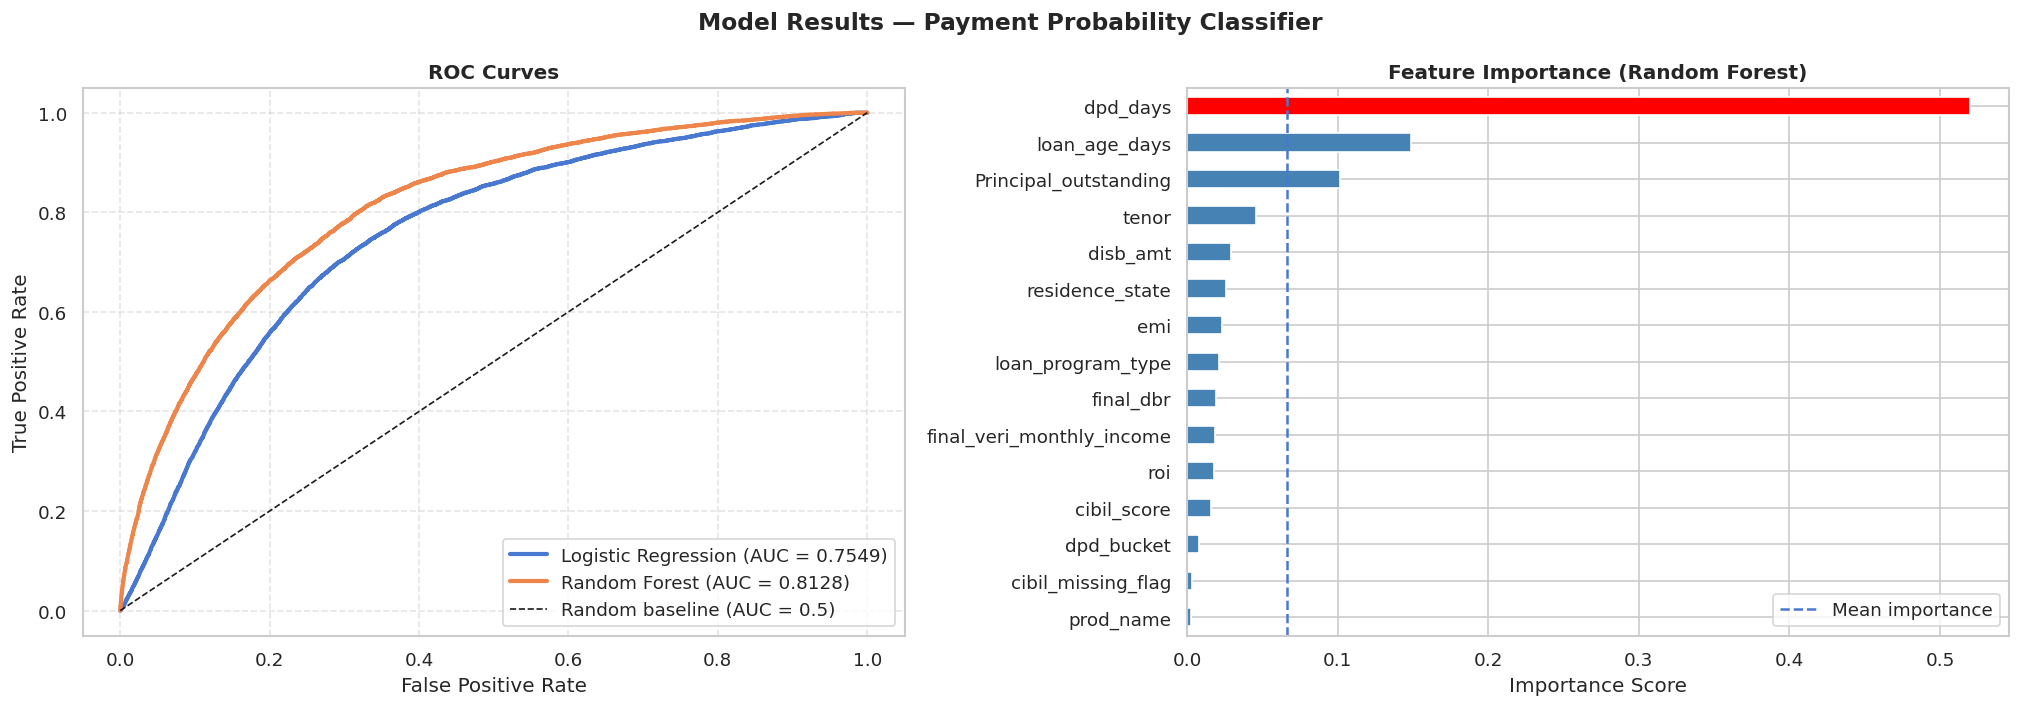

Saved: model_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Model Results — Payment Probability Classifier',
             fontsize=14, fontweight='bold')

# --- Chart 1: ROC Curves ---
for name, probs in [
    ('Logistic Regression', lr_probs),
    ('Random Forest', rf_probs)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    axes[0].plot(fpr, tpr, linewidth=2.5,
                 label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random baseline (AUC = 0.5)')

axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Chart 2: Feature Importance ---
#  FIX: Use actual model columns
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

# highlight top feature
top_feature = importances.idxmax()

colors = ['red' if f == top_feature else 'steelblue' for f in importances.index]

importances.plot(kind='barh', ax=axes[1], color=colors)

axes[1].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# mean line
axes[1].axvline(importances.mean(), linestyle='--', label='Mean importance')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: model_results.png")

### Feature Importance Interpretation

- `dpd_days` is the strongest predictor — customers with higher delinquency are less likely to pay  
- `loan_age_days` indicates older loans behave differently in recovery  
- Financial features (EMI, income, principal) contribute moderately  
- Product and location features have lower impact  

This suggests repayment behavior is primarily driven by delinquency status and loan lifecycle rather than demographics.

In [14]:
all_metrics = []

models = {
    'Logistic Regression': lr,
    'Random Forest': rf
}

tuned_threshold = 0.3  # important

for name, model in models.items():

    # Select correct input
    X_te = X_test_scaled if 'Logistic' in name else X_test

    # Probabilities
    probs = model.predict_proba(X_te)[:, 1]

    # Default predictions (0.5)
    preds_default = (probs >= 0.5).astype(int)

    # Tuned predictions (0.3)
    preds_tuned = (probs >= tuned_threshold).astype(int)

    # Confusion matrix (tuned)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_tuned).ravel()

    all_metrics.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, probs),

        'Precision (0.5)': precision_score(y_test, preds_default),
        'Recall (0.5)': recall_score(y_test, preds_default),

        'Precision (0.3)': precision_score(y_test, preds_tuned),
        'Recall (0.3)': recall_score(y_test, preds_tuned),

        'F1 (0.3)': f1_score(y_test, preds_tuned),

        'False Positives (0.3)': fp,
        'False Negatives (0.3)': fn
    })

comparison_df = pd.DataFrame(all_metrics)

print("\n--- MODEL COMPARISON (DEFAULT vs TUNED) ---")
print(comparison_df.sort_values(by='ROC-AUC', ascending=False).to_string(index=False))


--- MODEL COMPARISON (DEFAULT vs TUNED) ---
              Model  ROC-AUC  Precision (0.5)  Recall (0.5)  Precision (0.3)  Recall (0.3)  F1 (0.3)  False Positives (0.3)  False Negatives (0.3)
      Random Forest 0.812837         0.219686      0.707159         0.154810      0.884497  0.263501                  48497                   1160
Logistic Regression 0.754856         0.176502      0.724584         0.118645      0.914767  0.210046                  68246                    856


## Final Conclusion

This project successfully developed a machine learning model to predict whether a customer in loan recovery will make a payment.

### Key Findings:
- Only ~9% of account-months result in payments, indicating a highly imbalanced problem
- Payment behavior is strongly influenced by delinquency metrics (dpd_days, dpd_bucket)
- Recovery performance fluctuates month-to-month, with a dip observed in April

### Model Performance:
- Random Forest outperformed Logistic Regression (ROC-AUC: 0.81 vs 0.75)
- Threshold tuning improved recall significantly (up to ~88%), allowing better identification of potential payers

This model can be used to rank customers by payment probability, enabling targeted collection strategies.

### Recommendation:
Use Random Forest with a tuned threshold (0.3) for deployment, depending on business preference between recall and precision.

### Next Steps:
- Add behavioral features (past payment patterns)
- Perform hyperparameter tuning
- Deploy model as a scoring system
- Monitor performance over time for drift